Notebook to implement a script that takes a cue and foreground alongside many backgrounds and returns the backgrounds and their respective confusion scores (e.g. lowest softmax ouput)

In [2]:
import h5py
import importlib
import pathlib
import pickle
import sys
import torch
import yaml

import numpy as np
import src.audio_transforms as at

from src import attn_tracking_lightning
from tqdm import tqdm

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
root = pathlib.Path('/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/')

In [4]:
train_files = root.glob('train_*/*.h5')
eg_filename = next(train_files)

In [5]:
with h5py.File(eg_filename, 'r', swmr=True) as file:
            dataset_len = len(file['sources']['signal']['signal'])

In [6]:
file = h5py.File(eg_filename, 'r')
sources = file['sources']
target_keys = ['signal/word_int', 'signal/speaker_int', 'noise/labels_binary_via_int']

In [7]:
# first we select a foreground and a cue
# randomly select a foreground index
foreground_ix = np.random.randint(0, dataset_len)
foreground = sources['signal']['signal'][foreground_ix]
speaker_ix = sources['signal']['speaker_int'][foreground_ix]
label = sources['signal']['word_int'][foreground_ix]
# select a cue with the same speaker as the foreground
cue_ixs = np.where(sources['signal']['speaker_int'][:] == speaker_ix)[0]
cue_ixs = cue_ixs[cue_ixs != foreground_ix]
cue_ix = np.random.choice(cue_ixs)
assert sources['signal']['speaker_int'][cue_ix] == speaker_ix, 'Cue and foreground have different speakers'
assert cue_ix != foreground_ix, 'Cue and foreground are the same'
cue = sources['signal']['signal'][cue_ix]

In [8]:
# select a series of background noises
backgrounds = []
background_ixs = np.where(sources['signal']['speaker_int'][:] != speaker_ix)[0]
for i in range(10):
    background_ix = np.random.choice(background_ixs)
    assert sources['signal']['speaker_int'][background_ix] != speaker_ix, 'Background and foreground have the same speaker'
    background = sources['signal']['signal'][background_ix]
    background_speaker = sources['signal']['speaker_int'][background_ix]
    backgrounds.append((background, background_speaker, background_ix))

In [9]:
# load in model
importlib.reload(attn_tracking_lightning)

path = 'config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)
config['n_jobs'] = 10
ckpt_path = '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4/checkpoints/epoch=0-step=70000.ckpt'

AttentionalTrackingModule = attn_tracking_lightning.AttentionalTrackingModule
model = AttentionalTrackingModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config)

ln_first


In [10]:
# get audio transforms
bg_combine_transforms = at.AudioCompose([
                            at.AudioToTensor(),
                            at.CombineWithRandomDBSNR(low_snr=-10, high_snr=10), #soft code low and high snr when possible
                            at.RMSNormalizeForegroundAndBackground(rms_level=0.1),
                            at.UnsqueezeAudio(dim=0),
                            at.AudioToAudioRepresentation(**config['data']['audio']),
                            at.UnsqueezeAudio(dim=0),
                        ])

In [11]:
# create scenes
scenes = []
cue = bg_combine_transforms(cue, None)
for bg, bg_speak, bg_ix in backgrounds:
    scene = bg_combine_transforms(foreground, bg)
    scene_dict = {'scene': scene, 'cue': cue, 'foreground_ix': foreground_ix, 'label': label, 'speaker_ix': speaker_ix, 'cue_ix': cue_ix, 'bg_ix': bg_ix, 'bg_speaker': bg_speak,}
    scenes.append(scene_dict)

In [12]:
# run each scene through the model and get a confusion score
model = model.eval().cuda()
with torch.no_grad():
    for ix, scene_dict in tqdm(enumerate(scenes), total=10):
        mixture = scene_dict['scene'][0]
        cue = scene_dict['cue'][0]
        logits_out = model(cue.cuda(), mixture.cuda())
        softmax_out = torch.softmax(logits_out, dim=1)
        scene_dict['output'] = softmax_out.cpu().numpy()

100%|██████████| 10/10 [00:01<00:00,  8.38it/s]


In [13]:
for scene in scenes:
    correct = scene['label'] == np.argmax(scene['output'])
    scene['correct'] = correct
    label_confidence = scene['output'][0, scene['label']]
    scene['label_confidence'] = label_confidence
    model_confidence = np.max(scene['output'])
    scene['model_confidence'] = model_confidence

(0.0, 1.0)

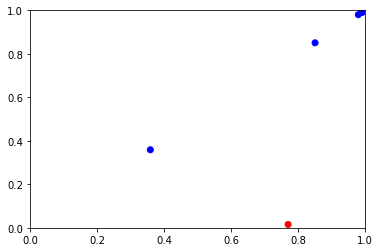

In [21]:
# plot model confidence vs label confidence and color based on correctness
%matplotlib inline
import matplotlib.pyplot as plt

model_confidences = [scene['model_confidence'] for scene in scenes]
label_confidences = [scene['label_confidence'] for scene in scenes]
color = ['b' if scene['correct'] else 'r' for scene in scenes]
plt.scatter(model_confidences, label_confidences, c=color)
plt.xlim([0, 1])
plt.ylim([0, 1])